# 01 — Data Exploration

Exploratory analysis of the synthetic customer-support dataset.

**Goals**
- Understand distributions of all variables
- Check treatment/control balance before any matching
- Identify confounding patterns

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.generate import generate_synthetic_conversations
from src.analysis.balance import balance_table

sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Load data

In [2]:
# Generate fresh or load from CSV if it already exists
import os
CSV = '../data/synthetic_conversations.csv'
if os.path.exists(CSV):
    df = pd.read_csv(CSV, parse_dates=['created_at'])
else:
    df = generate_synthetic_conversations(n=2000, seed=42)

print(df.shape)
df.head()

(2000, 11)


,conversation_id,created_at,period,ai_assisted,issue_severity,customer_tenure,time_of_day,agent_experience,resolution_time,satisfaction_score,escalated
0,381,2023-01-02,0,0,1,113,6,3,58.3,4.70,0
1,845,2023-01-02,0,0,3,90,6,6,75.3,2.75,0
2,901,2023-01-02,0,0,3,41,0,2,90.8,3.33,1
3,773,2023-01-02,0,0,2,21,23,6,71.2,2.36,0
4,846,2023-01-02,0,0,3,92,15,7,71.2,3.72,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   conversation_id     2000 non-null   int64         
 1   created_at          2000 non-null   datetime64[ns]
 2   period              2000 non-null   int64         
 3   ai_assisted         2000 non-null   int64         
 4   issue_severity      2000 non-null   int64         
 5   customer_tenure     2000 non-null   int64         
 6   time_of_day         2000 non-null   int64         
 7   agent_experience    2000 non-null   int64         
 8   resolution_time     2000 non-null   float64       
 9   satisfaction_score  2000 non-null   float64       
 10  escalated           2000 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(8)
memory usage: 172.0 KB


In [4]:
df.describe().T.round(2)

,count,mean,min,25%,50%,75%,max,std
conversation_id,2000.0,1000.5,1.0,500.75,1000.5,1500.25,2000.0,577.494589
created_at,2000,2023-12-31 10:45:07.200000,2023-01-02 00:00:00,2023-07-04 00:00:00,2023-12-31 12:00:00,2024-06-29 00:00:00,2024-12-30 00:00:00,NaN
period,2000.0,0.5,0.0,0.0,0.5,1.0,1.0,0.500125
ai_assisted,2000.0,0.1405,0.0,0.0,0.0,0.0,1.0,0.347592
issue_severity,2000.0,3.0045,1.0,2.0,3.0,4.0,5.0,1.410487
customer_tenure,2000.0,59.336,0.0,30.0,59.5,90.0,120.0,34.835756
time_of_day,2000.0,11.12,0.0,5.0,11.0,17.0,23.0,6.902132
agent_experience,2000.0,5.5155,1.0,3.0,6.0,8.0,10.0,2.810998
resolution_time,2000.0,64.89855,13.1,53.6,64.8,76.225,111.0,16.401671
satisfaction_score,2000.0,3.33208,1.0,2.76,3.34,3.92,5.0,0.81545


## 2. Treatment assignment

In [ ]:
print('Overall AI-assisted rate:', round(df['ai_assisted'].mean(), 3))
print()
print('By period:')
print(df.groupby('period')['ai_assisted'].mean().rename({0: 'pre', 1: 'post'}))

Overall AI-assisted rate: 0.14

By period:
period
pre     0.000
post    0.281
Name: ai_assisted, dtype: float64


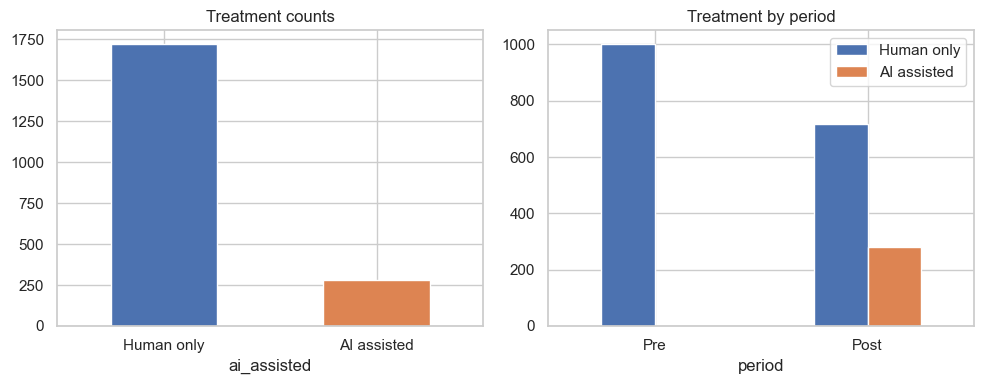

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df['ai_assisted'].value_counts().plot.bar(ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Treatment counts')
axes[0].set_xticklabels(['Human only', 'AI assisted'], rotation=0)

df.groupby(['period', 'ai_assisted']).size().unstack().plot.bar(
    ax=axes[1], color=['#4C72B0', '#DD8452']
)
axes[1].set_title('Treatment by period')
axes[1].set_xticklabels(['Pre', 'Post'], rotation=0)
axes[1].legend(['Human only', 'AI assisted'])

plt.tight_layout()
plt.show()

## 3. Outcome distributions

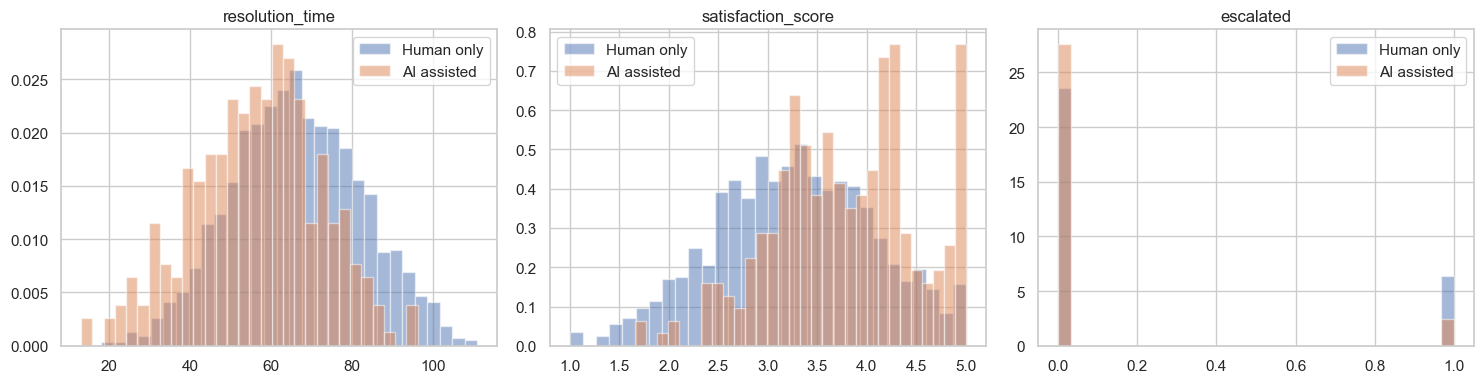

In [7]:
outcomes = ['resolution_time', 'satisfaction_score', 'escalated']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, outcomes):
    for treat, grp in df.groupby('ai_assisted'):
        label = 'AI assisted' if treat else 'Human only'
        grp[col].hist(ax=ax, alpha=0.5, bins=30, label=label, density=True)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# Unadjusted mean outcomes by treatment
df.groupby('ai_assisted')[outcomes].mean().rename(index={0: 'Human only', 1: 'AI assisted'}).round(3)

,resolution_time,satisfaction_score,escalated
ai_assisted,,,
Human only,66.281,3.258,0.213
AI assisted,56.442,3.782,0.082


## 4. Covariate distributions

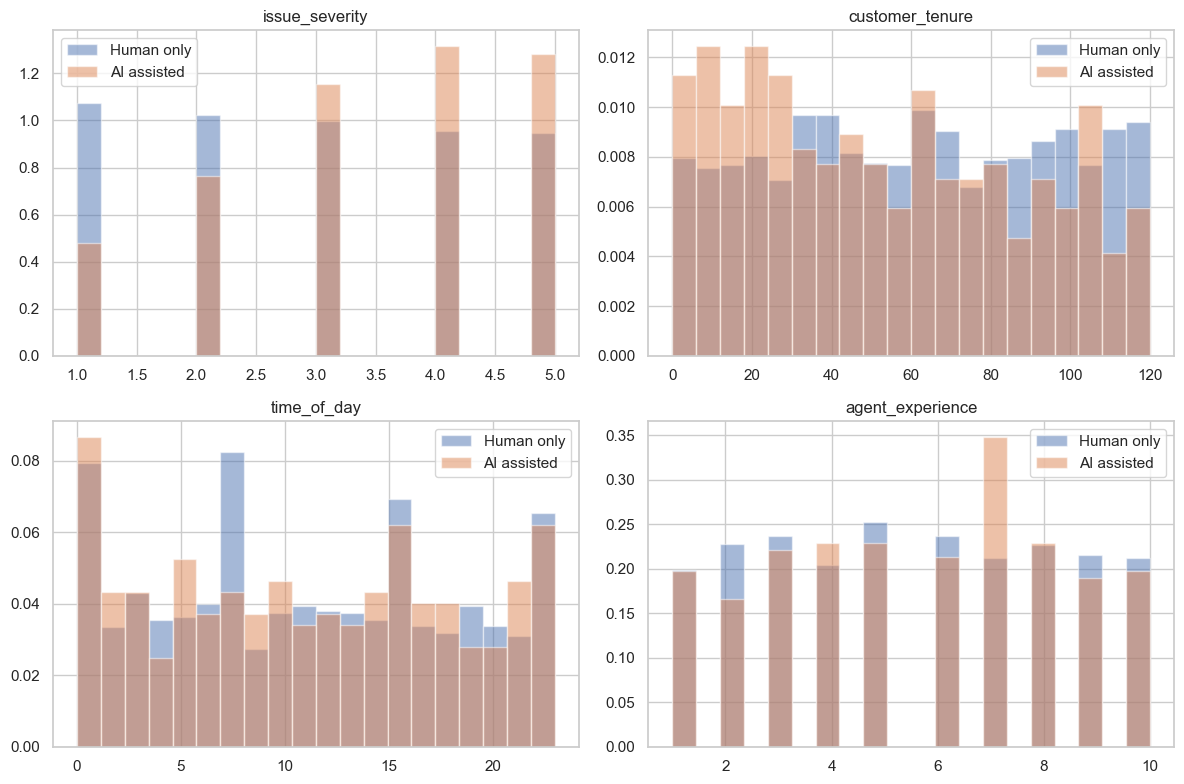

In [9]:
covariates = ['issue_severity', 'customer_tenure', 'time_of_day', 'agent_experience']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, covariates):
    for treat, grp in df.groupby('ai_assisted'):
        label = 'AI assisted' if treat else 'Human only'
        grp[col].hist(ax=ax, alpha=0.5, bins=20, label=label, density=True)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

## 5. Pre-matching covariate balance

In [10]:
bt = balance_table(df, treatment_col='ai_assisted', covariates=covariates)
bt.round(3)

,covariate,mean_treated,mean_control,smd
0,issue_severity,3.431,2.935,0.367
1,customer_tenure,51.929,60.547,-0.248
2,time_of_day,11.096,11.124,-0.004
3,agent_experience,5.623,5.498,0.045


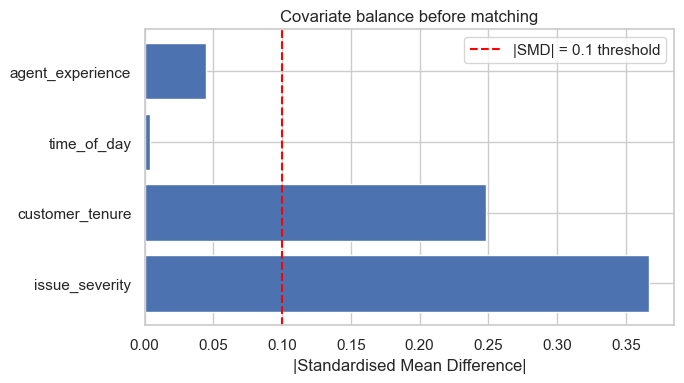

In [11]:
# Love plot — SMD before matching
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(bt['covariate'], bt['smd'].abs())
ax.axvline(0.1, color='red', linestyle='--', label='|SMD| = 0.1 threshold')
ax.set_xlabel('|Standardised Mean Difference|')
ax.set_title('Covariate balance before matching')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Correlation heatmap

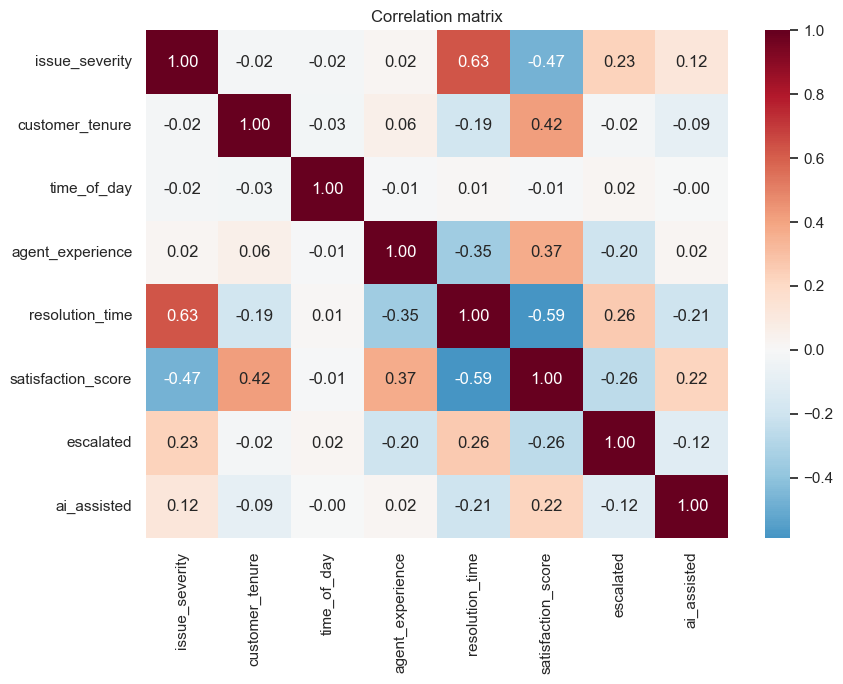

In [12]:
cols = covariates + outcomes + ['ai_assisted']
corr = df[cols].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Correlation matrix')
plt.tight_layout()
plt.show()

## 7. Time series — daily conversation volume

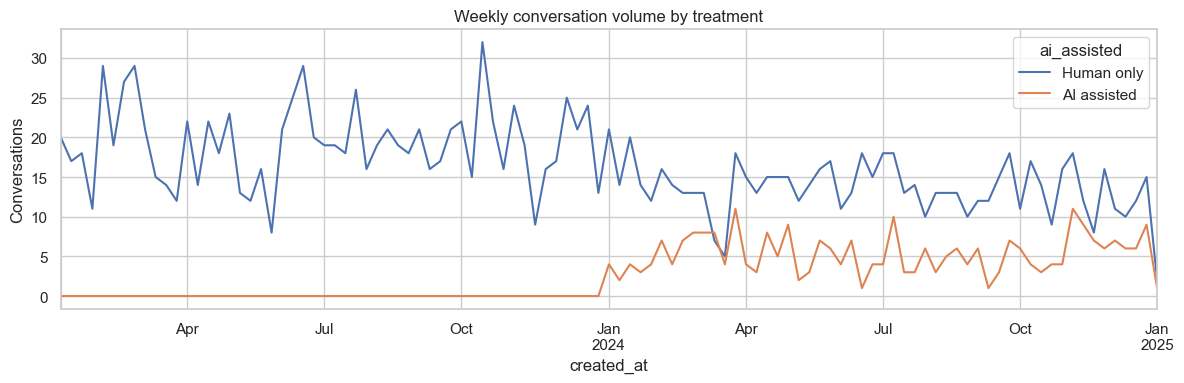

In [13]:
daily = (
    df.set_index('created_at')
    .groupby([pd.Grouper(freq='W'), 'ai_assisted'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: 'Human only', 1: 'AI assisted'})
)

daily.plot(figsize=(12, 4), title='Weekly conversation volume by treatment')
plt.ylabel('Conversations')
plt.tight_layout()
plt.show()